# Loan Approval Prediction

Predicts loan approval status from applicant income, assets, and credit data, comparing a Logistic Regression pipeline against tree-based models.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("loan_approval_dataset.csv")

In [2]:
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df[' loan_status'] = le.fit_transform(df[' loan_status'])

In [4]:
df[' loan_status'].unique()

array([0, 1])

In [5]:
print(df.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [6]:
df.shape

(4269, 13)

In [7]:
df.dtypes

loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                  int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   int64 
dtypes: int64(11), object(2)
memory usage: 433.7+ KB


In [9]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [10]:
df.duplicated(keep=False)

0       False
1       False
2       False
3       False
4       False
        ...  
4264    False
4265    False
4266    False
4267    False
4268    False
Length: 4269, dtype: bool

<Axes: xlabel=' bank_asset_value', ylabel=' loan_status'>

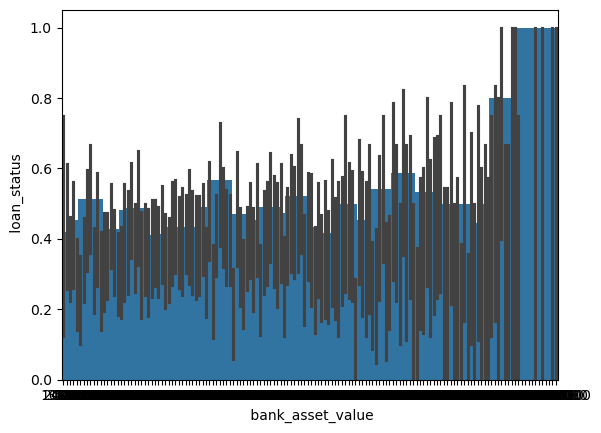

In [11]:
sns.barplot(data=df,x=' bank_asset_value',y=' loan_status',gap=10)

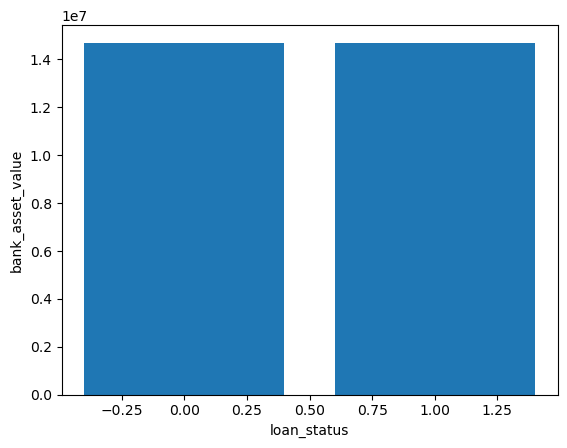

In [12]:
plt.bar(df[' loan_status'],df[' bank_asset_value'])
plt.xlabel("loan_status")
plt.ylabel("bank_asset_value")
plt.show()

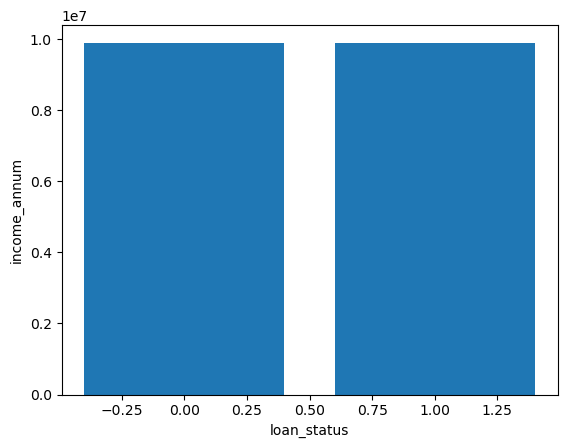

In [13]:
plt.bar(df[' loan_status'],df[' income_annum'])
plt.xlabel("loan_status")
plt.ylabel("income_annum")
plt.show()

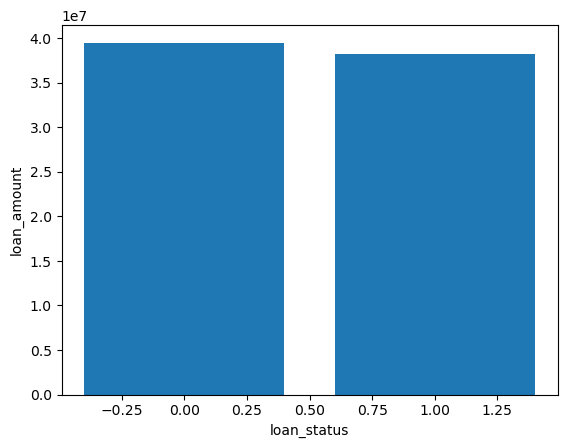

In [14]:
plt.bar(df[' loan_status'],df[' loan_amount'])
plt.xlabel("loan_status")
plt.ylabel("loan_amount")
plt.show()

<Axes: >

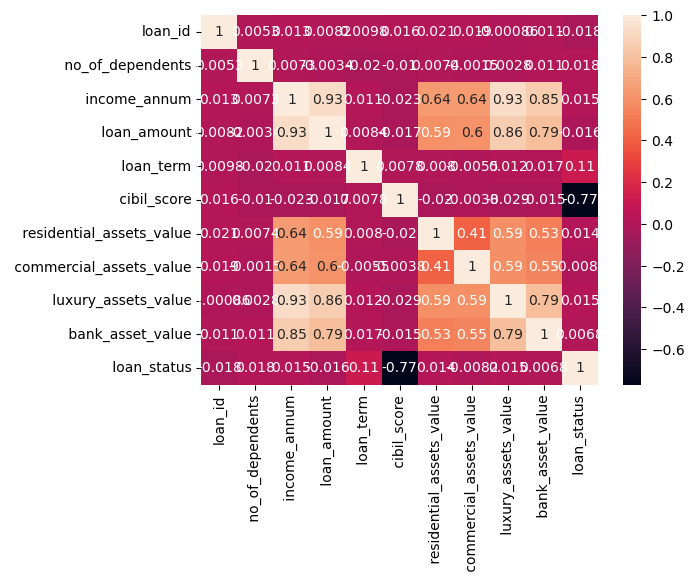

In [15]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

In [16]:
corr.sort_values(by=" loan_status",ascending=False)

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
loan_status,-0.017685,0.018114,0.015189,-0.016150,0.113036,-0.770518,0.014367,-0.008246,0.015465,0.006778,1.000000
loan_term,0.009809,-0.020111,0.011488,0.008437,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177,0.113036
no_of_dependents,0.005326,1.000000,0.007266,-0.003366,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163,0.018114
luxury_assets_value,-0.000862,0.002817,0.929145,0.860914,0.012490,-0.028618,0.590932,0.591128,1.000000,0.788517,0.015465
income_annum,0.012592,0.007266,1.000000,0.927470,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093,0.015189
residential_assets_value,0.020936,0.007376,0.636841,0.594596,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418,0.014367
bank_asset_value,0.010765,0.011163,0.851093,0.788122,0.017177,-0.015478,0.527418,0.548576,0.788517,1.000000,0.006778
commercial_assets_value,0.018595,-0.001531,0.640328,0.603188,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576,-0.008246
loan_amount,0.008170,-0.003366,0.927470,1.000000,0.008437,-0.017035,0.594596,0.603188,0.860914,0.788122,-0.016150
loan_id,1.000000,0.005326,0.012592,0.008170,0.009809,0.016323,0.020936,0.018595,-0.000862,0.010765,-0.017685


In [17]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [18]:
X=df.drop(" loan_status",axis=1)

In [19]:
y=df[' loan_status']

In [20]:
X=pd.get_dummies(X)

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [22]:
pipeline=Pipeline([
    ("scaler",StandardScaler()),
    ("model",LogisticRegression())
])

In [23]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

In [24]:
y_pred=pipeline.predict(X_test)

In [25]:
accuracy_score(y_test,y_pred)

0.9215456674473068

In [26]:
precision_score(y_test,y_pred)

0.9155844155844156

In [27]:
recall_score(y_test,y_pred)

0.8730650154798761

In [28]:
f1_score(y_test,y_pred)

0.8938193343898574

In [29]:
print(roc_auc_score(y_test,y_pred))

0.9120503985120662


In [30]:
param_grid={
    'model__penalty':['l2'],
    'model__C':[1.0],
    'model__max_iter':[10000,20]
}

In [31]:
grid=GridSearchCV(pipeline,param_grid,scoring='accuracy',cv=4)

In [32]:
grid.fit(X_train,y_train)

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', LogisticRegression())]),
             param_grid={'model__C': [1.0], 'model__max_iter': [10000, 20],
                         'model__penalty': ['l2']},
             scoring='accuracy')

In [33]:
grid.best_params_

{'model__C': 1.0, 'model__max_iter': 10000, 'model__penalty': 'l2'}

In [34]:
print(grid.best_score_)

0.9106909488758508


In [35]:
m2=DecisionTreeClassifier()

In [36]:
m2.fit(X_train,y_train)

DecisionTreeClassifier()

In [37]:
y_pred2=m2.predict(X_test)

In [38]:
accuracy_score(y_test,y_pred2)

0.9754098360655737

In [39]:
precision_score(y_test,y_pred2)

0.9748427672955975

In [40]:
recall_score(y_test,y_pred2)

0.9597523219814241

In [41]:
f1_score(y_test,y_pred2)

0.9672386895475819

In [42]:
print(roc_auc_score(y_test,y_pred2))

0.9723432043052129


In [43]:
param_grid2={
    'criterion':['gini'],
    'max_depth':[10,20,30],
    'min_samples_split':[3,4,5]
}

In [44]:
grid2=GridSearchCV(m2,param_grid2,scoring='accuracy',cv=4)

In [45]:
grid2.fit(X_train,y_train)

GridSearchCV(cv=4, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini'], 'max_depth': [10, 20, 30],
                         'min_samples_split': [3, 4, 5]},
             scoring='accuracy')

In [46]:
grid2.best_params_

{'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 5}

In [47]:
print(grid2.best_score_)

0.9742313257246087


In [48]:
m3=RandomForestClassifier()

In [49]:
m3.fit(X_train,y_train)

RandomForestClassifier()

In [50]:
y_pred3=m3.predict(X_test)

In [51]:
accuracy_score(y_test,y_pred3)

0.9824355971896955

In [52]:
precision_score(y_test,y_pred3)

0.9904458598726115

In [53]:
recall_score(y_test,y_pred3)

0.9628482972136223

In [54]:
f1_score(y_test,y_pred3)

0.9764521193092621

In [55]:
print(roc_auc_score(y_test,y_pred3))

0.978599289849749


In [56]:
param_grid3={
    'n_estimators':[100],
    'max_depth':[20,30,5],
    'min_samples_split':[30,20,10],
    'criterion':['gini']
}

In [57]:
grid3=GridSearchCV(m3,param_grid3,scoring='accuracy',cv=4)

In [58]:
grid3.fit(X_train,y_train)

GridSearchCV(cv=4, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini'], 'max_depth': [20, 30, 5],
                         'min_samples_split': [30, 20, 10],
                         'n_estimators': [100]},
             scoring='accuracy')

In [59]:
grid3.best_params_

{'criterion': 'gini',
 'max_depth': 30,
 'min_samples_split': 10,
 'n_estimators': 100}

In [61]:
print(grid3.best_score_)

0.9759891387608413


In [65]:
results=[]
model={
    'LogisticRegression':pipeline,
    'DecisionTreeClassifier':m2,
    'RandomForestClassifier':m3
}
predictions={
    'LogisticRegression':y_pred,
    'DecisionTreeClassifier':y_pred2,
    'RandomForestClassifier':y_pred3
}
for name in model.keys():

    results.append([
        name,
        accuracy_score(y_test, predictions[name]),
        precision_score(y_test, predictions[name]),
        recall_score(y_test, predictions[name]),
        f1_score(y_test, predictions[name])
    ])

In [66]:
comparison_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1'
    ]
)

comparison_df

,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression,0.921546,0.915584,0.873065,0.893819
1,DecisionTreeClassifier,0.975410,0.974843,0.959752,0.967239
2,RandomForestClassifier,0.982436,0.990446,0.962848,0.976452


In [67]:
comparison_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
2,RandomForestClassifier,0.982436,0.990446,0.962848,0.976452
1,DecisionTreeClassifier,0.975410,0.974843,0.959752,0.967239
0,LogisticRegression,0.921546,0.915584,0.873065,0.893819


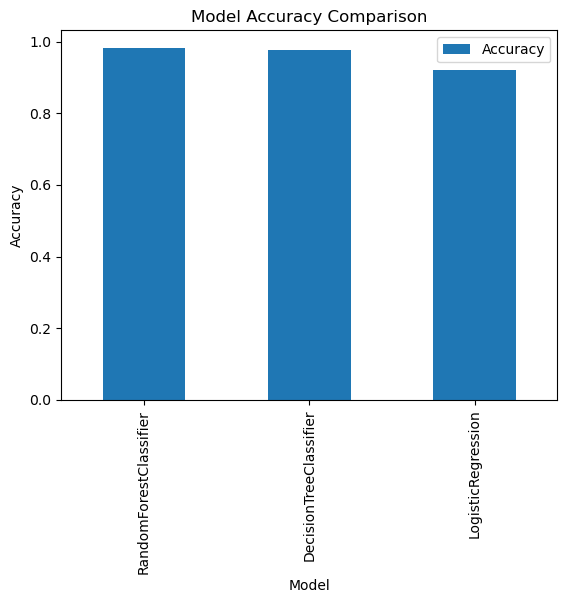

In [68]:
import matplotlib.pyplot as plt

comparison_df.sort_values(
    by='Accuracy',
    ascending=False
).plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

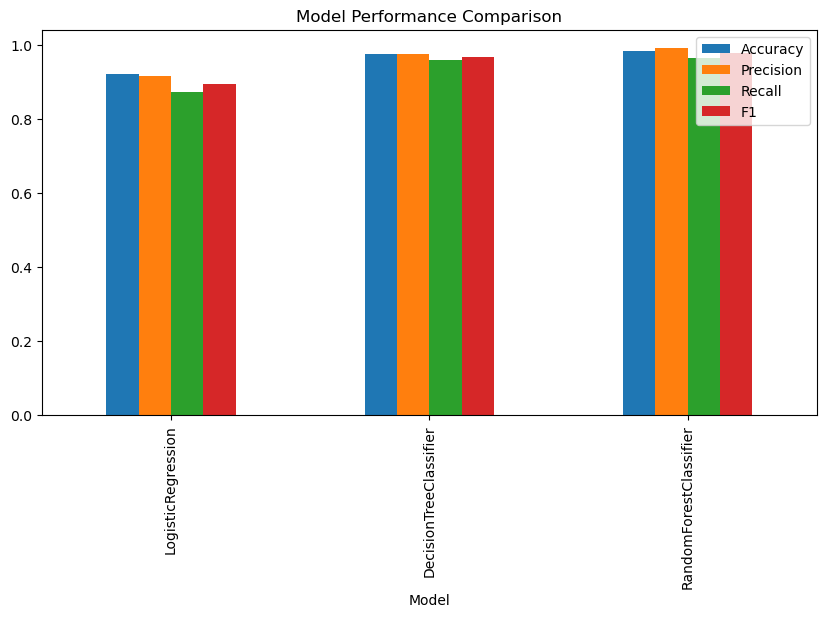

In [69]:
comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Model Performance Comparison')
plt.show()

In [70]:
best_model = m3

In [72]:
import joblib

joblib.dump(best_model,
            'loan_predictor.pkl')

['loan_predictor.pkl']

In [73]:
loaded_model = joblib.load(
    'loan_predictor.pkl'
)

## Summary

**Dataset:** loan_approval_dataset.csv — income, loan amount, asset values, CIBIL score → loan_status

**Steps:** Label-encoded target → EDA (bar plots, correlation heatmap) → one-hot encoding → built a scaled Logistic Regression pipeline, plus tuned Decision Tree and Random Forest, all via GridSearchCV.

**Results:** Random Forest performed best — Accuracy 98.2%, Precision 99.0%, Recall 96.3%, F1 97.7%, ROC-AUC 97.9%.

**Next steps:** Check for potential data leakage given the high accuracy; add feature importance analysis.